Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

Load Dataset

In [2]:
df = pd.read_csv("../data/cleaned_ecommerce.csv")

Select Features for Clustering

In [3]:
features = df[['price','month','day','hour']]

Feature Scaling

In [4]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

Elbow Method (Find Best K)

In [5]:
inertia = []

for k in range(1,10):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    kmeans.fit(scaled_features)
    
    inertia.append(kmeans.inertia_)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:8

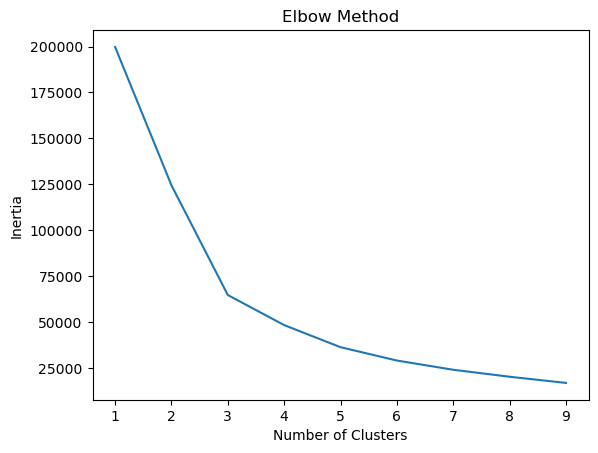

In [6]:
plt.plot(range(1,10), inertia)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

# Apply K-Means

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['cluster'] = kmeans.fit_predict(scaled_features)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [8]:
df['cluster'].value_counts()

2    38158
3    28699
1    22603
0    10450
Name: cluster, dtype: int64

Cluster Visualization

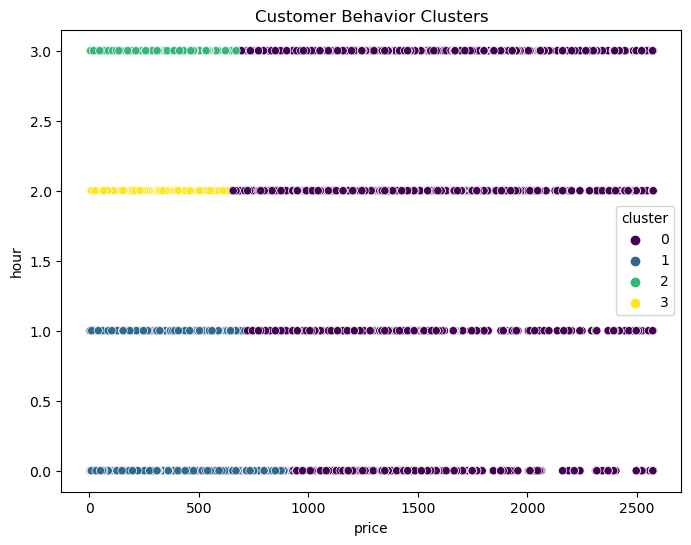

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['price'],
    y=df['hour'],
    hue=df['cluster'],
    palette='viridis'
)

plt.title("Customer Behavior Clusters")

plt.show()

# Hierarchical Clustering

In [11]:
sample = scaled_features[:1000]

In [12]:
linked = linkage(sample, method='ward')

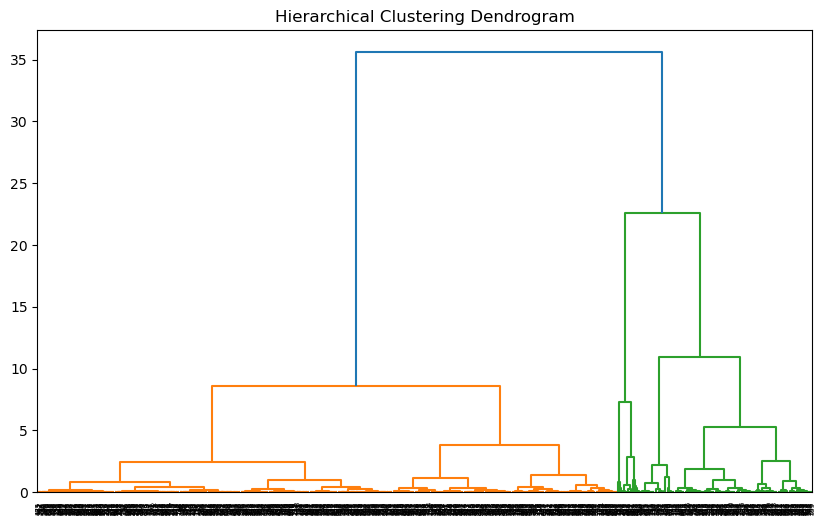

In [13]:
plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.show()

K-Means clustering grouped customer behavior into distinct clusters based on
price and interaction time.

Hierarchical clustering provided a dendrogram visualization showing
relationships between customer behavior patterns.